In [1]:
import itertools

from matplotlib import pyplot as plt

from cr_knee_fit import experiments
from cr_knee_fit.elements import Element
from cr_knee_fit.fit_data import CRSpectrumData, Data, DataConfig, FluxRatioData, SpectrumDataConfig
from cr_knee_fit.plotting import (
    CARTO_VIVID,
    PosteriorPlotConfig,
    plot_model_predictions,
)
from cr_knee_fit.utils import R_GV_LABEL, legend_artist_line, legend_with_added_items

In [2]:
ignore = {experiments.lhaaso_epos, experiments.lhaaso_qgsjet}

ALL = experiments.DIRECT + experiments.INDIRECT
conf = DataConfig(
    spectra=[
        SpectrumDataConfig(exp, element)
        for exp, element in itertools.product(ALL, Element.regular())
        if exp not in ignore
    ]
    + [
        SpectrumDataConfig.allparticle(exp)
        for exp in ALL
        if exp is not experiments.dampe
        if exp not in ignore
    ],
    lnA=[experiments.lhaaso_sibyll, experiments.tale],
)

d = Data.load(conf, verbose=True)

✅ AMS-02 H
✅ AMS-02 He
✅ AMS-02 Li
✅ AMS-02 Be
✅ AMS-02 B
✅ AMS-02 C
✅ AMS-02 N
✅ AMS-02 O
✅ AMS-02 F
✅ AMS-02 Ne
❌ AMS-02 Na: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Na_energy.txt not found.
✅ AMS-02 Mg
✅ AMS-02 Al
✅ AMS-02 Si
❌ AMS-02 P: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_P_energy.txt not found.
✅ AMS-02 S
❌ AMS-02 Cl: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Cl_energy.txt not found.
❌ AMS-02 Ar: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Ar_energy.txt not found.
❌ AMS-02 K: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_K_energy.txt not found.
❌ AMS-02 Ca: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Ca_energy.txt not found.
❌ AMS-02 Sc: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Sc_energy.txt not found.
❌ AMS-02 Ti: /Users/njvh/Documents/Sci

In [3]:
import numpy as np

from cr_knee_fit.fit_data import GenericExperimentData


def load_gamma_spectrum(fname: str, custom_label: str):
    E_TeV, F, Fstat, Fsyst = np.loadtxt(fname, unpack=True)
    Fconv = 1e-3 * 1e4  # TeV^-1 cm^-2 -> GeV^-1 m^-2

    return CRSpectrumData(
        d=GenericExperimentData(
            x=E_TeV * 1e3,
            y=F * Fconv,
            err_stat=np.vstack((Fstat, Fstat)).T * Fconv,
            err_syst=np.vstack((Fsyst, Fsyst)).T * Fconv,
            experiment=experiments.lhaaso_sibyll,
            custom_label=custom_label,
        ),
        spec="gamma",
        quantity="E",
    )

In [4]:
gamma_outer = load_gamma_spectrum("../data/lake/LHAASO_outerGalaxy.txt", " (outer)")
gamma_inner = load_gamma_spectrum("../data/lake/LHAASO_innerGalaxy.txt", " (inner)")

d.spectra.extend((gamma_inner, gamma_outer))

Spectra:
AMS-02
    AMS-02 H: 72 points from 1.1e+00 to 1.4e+03 GeV; total relative error from 0.88% to 4.92%
    AMS-02 He: 68 points from 4.1e+00 to 4.6e+03 GeV; total relative error from 1.28% to 7.97%
    AMS-02 Li: 67 points from 6.1e+00 to 6.1e+03 GeV; total relative error from 2.59% to 20.81%
    AMS-02 Be: 67 points from 8.1e+00 to 8.1e+03 GeV; total relative error from 2.75% to 39.32%
    AMS-02 B: 66 points from 1.1e+01 to 1.0e+04 GeV; total relative error from 2.39% to 20.39%
    AMS-02 C: 68 points from 1.2e+01 to 1.4e+04 GeV; total relative error from 2.27% to 11.30%
    AMS-02 N: 66 points from 1.6e+01 to 1.4e+04 GeV; total relative error from 3.13% to 14.02%
    AMS-02 F: 48 points from 2.0e+01 to 1.7e+04 GeV; total relative error from 3.38% to 75.55%
    AMS-02 Ne: 48 points from 2.3e+01 to 1.9e+04 GeV; total relative error from 3.42% to 12.77%
    AMS-02 O: 67 points from 1.8e+01 to 1.9e+04 GeV; total relative error from 2.67% to 11.72%
    AMS-02 Mg: 66 points from 2.

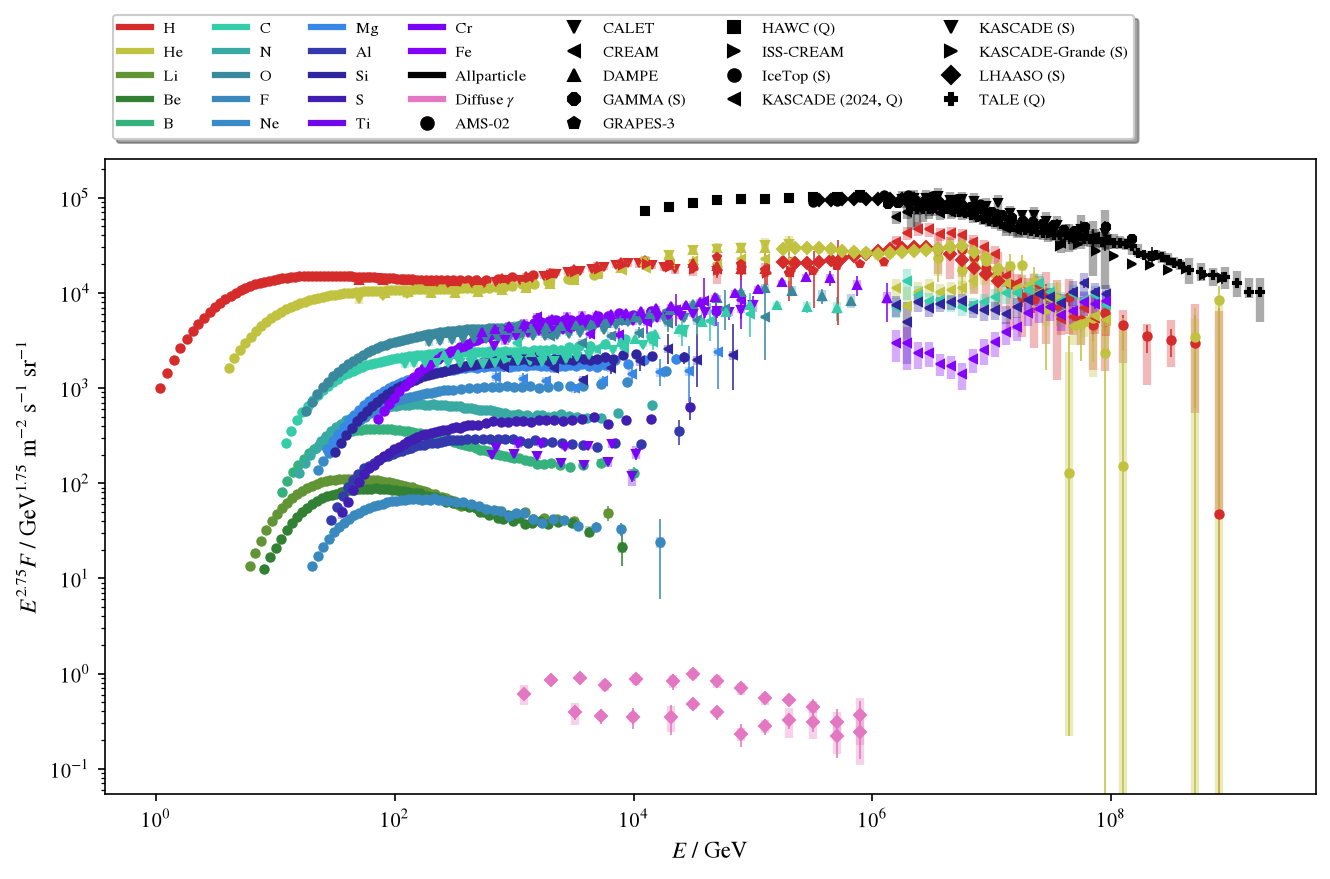

In [5]:
from cr_knee_fit.plotting import ALL_PARTICLE_COLOR

fig, ax = plt.subplots(figsize=(9, 6))
d.plot_spectra(describe=True, scale=2.75, is_fitted=True, ax=ax)
# ax.legend()
legend_with_added_items(
    ax,
    [(legend_artist_line(el.color, linewidth=3), el.name) for el in d.elements()]
    + [
        (legend_artist_line(ALL_PARTICLE_COLOR, linewidth=3), "Allparticle"),
        (legend_artist_line("tab:pink", linewidth=3), "Diffuse $\\gamma$"),
    ]
    + [(exp.legend_artist(True), exp.name) for exp in sorted(d.experiments(spectra_only=True))],
    fontsize="x-small",
    bbox_to_anchor=(0.00, 1.02, 1.0, 0.0),
    loc="lower left",
    fancybox=True,
    shadow=True,
    ncol=7,
)
fig.tight_layout()

lnA data:
    LHAASO (S) <lnA>: 20 points from 3.5e+05 to 2.8e+07 GeV; total relative error from 5.21% to 9.42%
    TALE (Q) <lnA>: 17 points from 3.5e+07 to 2.5e+09 GeV; total relative error from 15.08% to 208.50%


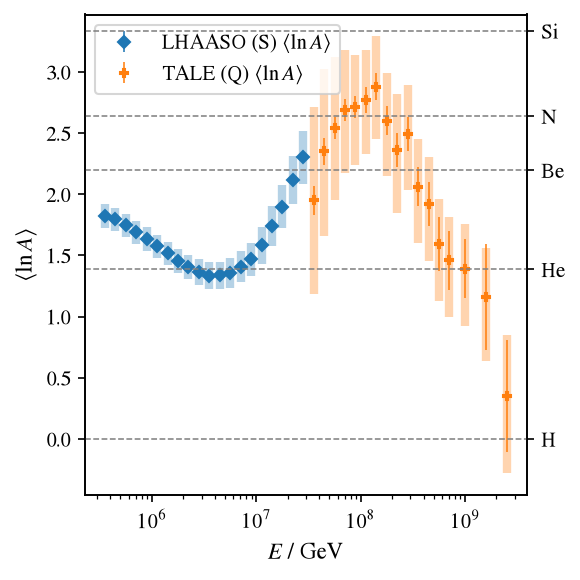

In [6]:
from cr_knee_fit.utils import add_elements_lnA_secondary_axis

fig, ax = plt.subplots(figsize=(4, 4))
d.plot_lnA(describe=True, is_fitted=True, ax=ax)
add_elements_lnA_secondary_axis(ax)
leg = ax.legend()
leg.set_zorder(100)
fig.tight_layout()

In [7]:
lhaaso = experiments.lhaaso_sibyll

p = CRSpectrumData.load(lhaaso, Element.H)
He = CRSpectrumData.load(lhaaso, Element.He)

# fig, ax = plt.subplots()
# p.to_quantity("R").plot(scale=2.8, ax=ax)
# He.to_quantity("R").plot(scale=2.8, ax=ax)
# ax.set_xscale("log")
# ax.set_yscale("log")

lhaaso_p_He = FluxRatioData.from_fluxes(p, He, quantity="R")
# ax = lhaaso_p_He.plot()
# ax.set_xscale("log")
# ax.set_yscale("log")

In [8]:
dampe_p_He = FluxRatioData.from_fluxes(
    CRSpectrumData.load(experiments.dampe, Element.H),
    CRSpectrumData.load(experiments.dampe, Element.He),
    quantity="R",
)
# ax = dampe_p_He.plot()
# ax.set_xscale("log")
# ax.set_yscale("log")

In [9]:
from cr_knee_fit.analysis import AnalysisResults

onepop_res = AnalysisResults.load("../out/phase-6/crams_high_E_feature_break", subsample_size=300)
fiducial_res = AnalysisResults.load("../out/phase-6/twopop_kneebump", subsample_size=300)
threepop_res = AnalysisResults.load("../out/phase-6/threepop_kneebump", subsample_size=300)

In [10]:
from matplotlib.axes import Axes

p_over_He = Element.H / Element.He
ams = FluxRatioData.load(experiments.ams02, p_over_He)
calet = FluxRatioData.load(experiments.calet, p_over_He)

p_He_data = Data(config=DataConfig(), flux_ratios=[ams, calet])
p_He_data.flux_ratios.append(dampe_p_He)
p_He_data.flux_ratios.append(lhaaso_p_He)


def plot_p_He_data() -> Axes:
    _, ax = plt.subplots(figsize=(5, 4))
    for i, fr in enumerate(p_He_data.flux_ratios):
        fr.plot_in_R(
            ax=ax, is_fitted=True, color=CARTO_VIVID(i + 4), add_legend_label=fr.d.plot_label()
        )
    ax.set_xscale("log")
    ax.set_xlabel(R_GV_LABEL)
    ax.set_ylabel("H / He")
    return ax

/Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/cr_knee_fit/crams_model.py:543: RuntimeWarning: divide by zero encountered in log10
  return np.log10(self.crams.compute(self.propagation, self.injection))


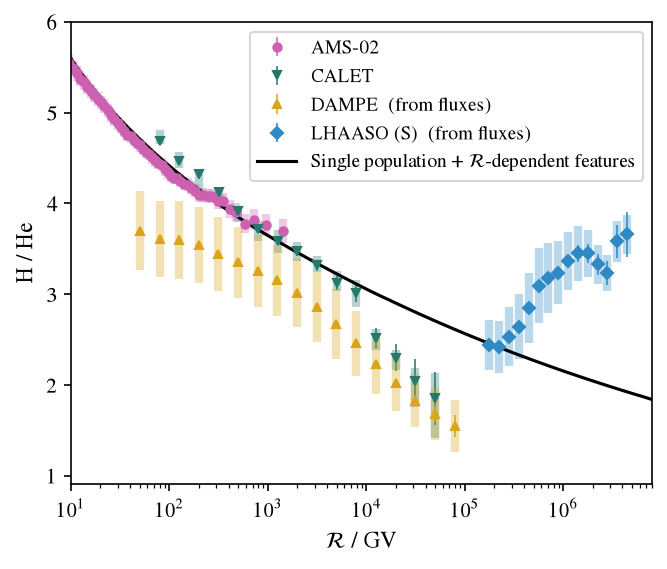

In [11]:
ax = plot_p_He_data()

Rmin = 10
Rmax = 8e6
plot_model_predictions(
    ax=ax,
    scale=0,
    E_bounds=(Rmin, Rmax),
    model_sample=onepop_res.posterior_sample,
    observable=lambda m, R: m.compute_flux_ratio(R, Element.H / Element.He, "R"),
    color="k",
    plot_config=PosteriorPlotConfig(band_cl=None),
    best=onepop_res.mle,
)

legend_with_added_items(
    ax,
    items=[
        (legend_artist_line("black"), "Single population + $\\mathcal {R}$-dependent features"),
    ],
    fontsize="small",
)

ax.set_xlim(Rmin, Rmax)
ax.set_ylim(top=6)
ax.set_yscale("linear")

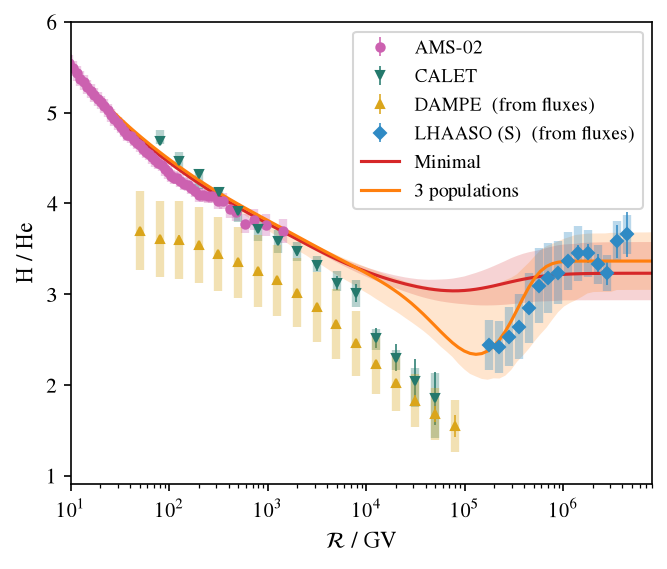

In [12]:
ax = plot_p_He_data()

Rmin = 10
Rmax = 8e6
for res, color in (
    (fiducial_res, "tab:red"),
    (threepop_res, "tab:orange"),
):
    plot_model_predictions(
        ax=ax,
        scale=0,
        E_bounds=(Rmin, Rmax),
        model_sample=res.posterior_sample,
        observable=lambda m, R: m.compute_flux_ratio(R, Element.H / Element.He, "R"),
        color=color,
        plot_config=PosteriorPlotConfig(),
        best=res.mle,
    )

legend_with_added_items(
    ax,
    items=[
        (legend_artist_line("tab:red"), "Minimal"),
        (legend_artist_line("tab:orange"), "3 populations"),
    ],
    fontsize="small",
)

ax.set_xlim(Rmin, Rmax)
ax.set_ylim(top=6)
ax.set_yscale("linear")